# Modèle de Régression Logistique pour la Prédiction d'Admission à l'Université

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger les données
data = pd.read_csv('ex2data1.txt', header=None, names=['Exam 1 Score', 'Exam 2 Score', 'Admitted'])

# Afficher les premières lignes
print("Premières lignes de l'ensemble de données :")
display(data.head())

# Afficher les informations générales sur les données
print("\nInformations sur l'ensemble de données :")
display(data.info())

# Afficher les statistiques descriptives
print("\nStatistiques descriptives de l'ensemble de données :")
display(data.describe())

Premières lignes de l'ensemble de données :


,Exam 1 Score,Exam 2 Score,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1



Informations sur l'ensemble de données :
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Exam 1 Score  100 non-null    float64
 1   Exam 2 Score  100 non-null    float64
 2   Admitted      100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


None


Statistiques descriptives de l'ensemble de données :


,Exam 1 Score,Exam 2 Score,Admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


## Visualisation des données

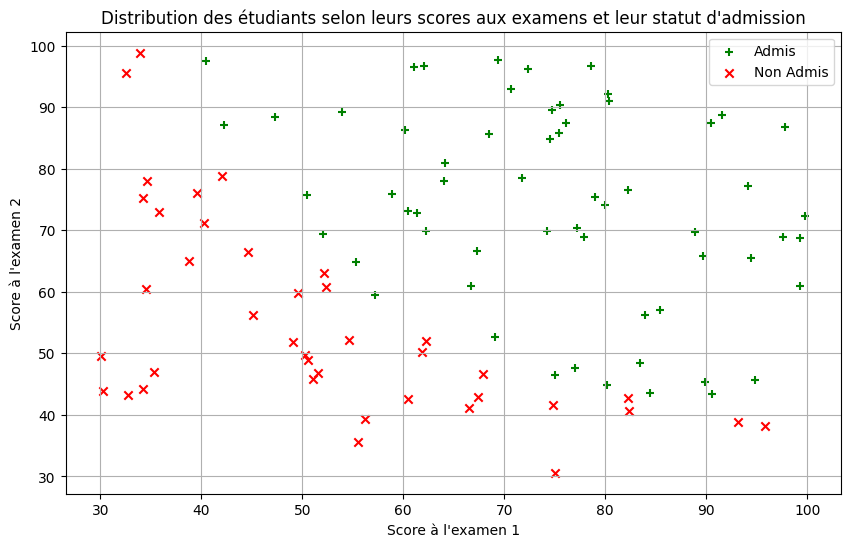

In [7]:
# Créer un nuage de points pour visualiser les données

# Séparer les étudiants admis (Admitted = 1) et non admis (Admitted = 0)
admitted = data[data['Admitted'] == 1]
not_admitted = data[data['Admitted'] == 0]

plt.figure(figsize=(10, 6))
plt.scatter(admitted['Exam 1 Score'], admitted['Exam 2 Score'], color='green', marker='+', label='Admis')
plt.scatter(not_admitted['Exam 1 Score'], not_admitted['Exam 2 Score'], color='red', marker='x', label='Non Admis')

plt.xlabel('Score à l\'examen 1')
plt.ylabel('Score à l\'examen 2')
plt.title('Distribution des étudiants selon leurs scores aux examens et leur statut d\'admission')
plt.legend()
plt.grid(True)
plt.show()

## Application de la Régression Logistique avec Scikit-learn

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Préparer les données pour le modèle
# X contient les scores des examens (caractéristiques)
# y contient le statut d'admission (variable cible)
X = data[['Exam 1 Score', 'Exam 2 Score']]
y = data['Admitted']

# Initialiser le modèle de régression logistique
# Nous utilisons 'liblinear' comme solveur pour les petits ensembles de données et la régularisation L1/L2
model = LogisticRegression(solver='liblinear')

# Entraîner le modèle
model.fit(X, y)

print("Modèle de régression logistique entraîné avec succès.")
print(f"Coefficients du modèle : {model.coef_[0]}")
print(f"Ordonnée à l'origine (intercept) : {model.intercept_[0]}")

Modèle de régression logistique entraîné avec succès.
Coefficients du modèle : [0.03844482 0.03101855]
Ordonnée à l'origine (intercept) : -3.8997779447047463


## Faire des Prédictions et Évaluer le Modèle

Précision du modèle sur l'ensemble d'entraînement : 0.87


c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


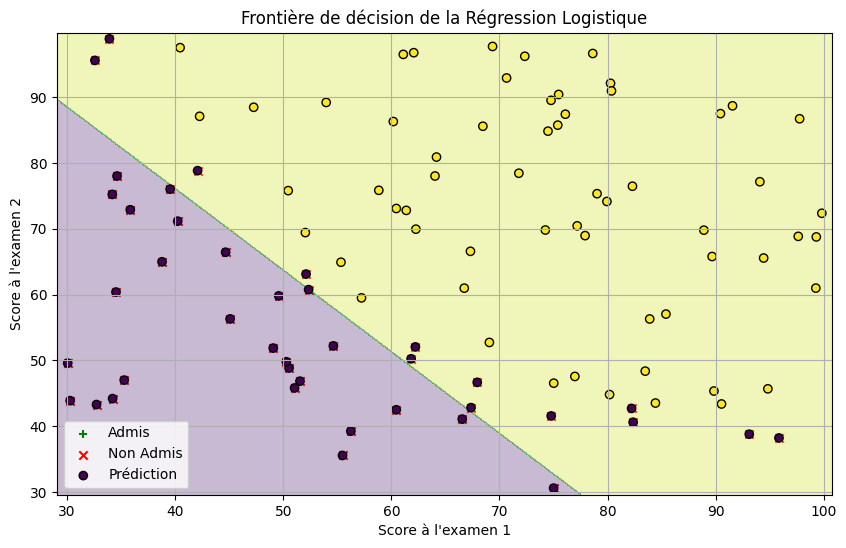


Interprétation du modèle :
Les coefficients du modèle (0.04 pour l'Examen 1 et 0.03 pour l'Examen 2) indiquent l'influence de chaque score sur la probabilité d'admission. Un coefficient positif signifie qu'une augmentation du score augmente la probabilité d'admission.
L'ordonnée à l'origine (-3.90) représente la probabilité log-odds d'admission lorsque les scores des examens sont nuls.
La précision du modèle de 0.87 signifie que le modèle a correctement prédit le statut d'admission pour 87% des étudiants dans cet ensemble de données.
Le graphique de la frontière de décision montre comment le modèle sépare les étudiants admis des non-admis en fonction de leurs scores aux deux examens.


In [9]:
# Faire des prédictions sur l'ensemble de données d'entraînement
y_pred = model.predict(X)

# Calculer la précision du modèle
accuracy = accuracy_score(y, y_pred)

print(f"Précision du modèle sur l'ensemble d'entraînement : {accuracy:.2f}")

# Créer un graphique de la frontière de décision
plt.figure(figsize=(10, 6))

# Nuage de points des données originales
plt.scatter(admitted['Exam 1 Score'], admitted['Exam 2 Score'], color='green', marker='+', label='Admis')
plt.scatter(not_admitted['Exam 1 Score'], not_admitted['Exam 2 Score'], color='red', marker='x', label='Non Admis')

# Créer une grille pour tracer la frontière de décision
x_min, x_max = X['Exam 1 Score'].min() - 1, X['Exam 1 Score'].max() + 1
y_min, y_max = X['Exam 2 Score'].min() - 1, X['Exam 2 Score'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X['Exam 1 Score'], X['Exam 2 Score'], c=y, edgecolors='k', cmap='viridis', label='Prédiction')

plt.xlabel('Score à l\'examen 1')
plt.ylabel('Score à l\'examen 2')
plt.title('Frontière de décision de la Régression Logistique')
plt.legend()
plt.grid(True)
plt.show()

# Interpréter les résultats
print("\nInterprétation du modèle :")
print(f"Les coefficients du modèle ({model.coef_[0][0]:.2f} pour l'Examen 1 et {model.coef_[0][1]:.2f} pour l'Examen 2) indiquent l'influence de chaque score sur la probabilité d'admission. Un coefficient positif signifie qu'une augmentation du score augmente la probabilité d'admission.")
print(f"L'ordonnée à l'origine ({model.intercept_[0]:.2f}) représente la probabilité log-odds d'admission lorsque les scores des examens sont nuls.")
print(f"La précision du modèle de {accuracy:.2f} signifie que le modèle a correctement prédit le statut d'admission pour {accuracy*100:.0f}% des étudiants dans cet ensemble de données.")
print("Le graphique de la frontière de décision montre comment le modèle sépare les étudiants admis des non-admis en fonction de leurs scores aux deux examens.")